[Home](../../README.md)

### Feature Engineering

This Jupyter Notepad is a selection of data engineering processes I have applied to my data before model training to maximise the performance of your machine learning model. Here, I engineer new / improved features for the Spotify data I previously wrangled.

#### Feature Engineering Process
- Deriving new variables from existing ones
    - Encoding categorical features
    - Calculating new features from existing features
- Combining features/feature interactions
- Identifying the most relevant features for the model
- Transforming Features
  - [Dividing Data into categories](https://web.ma.utexas.edu/users/mks/statmistakes/dividingcontinuousintocategories.html)
  - Mathematical transformations (for example logarithmic transformations). Logarithmic transformations are a powerful tool in the world of statistical analysis. They are often used to transform data that exhibit skewness or other irregularities, making it easier to analyze, visualize, and interpret the results.
- Creating Domain-Specific Features that incorporating knowledge from the specific domain to create features that capture important characteristics of the data.

#### Load the required dependencies

In [1]:
# Import frameworks
import pandas as pd

####  Store the data as a local variable

The data frame is a Pandas object that structures your tabular data into an appropriate format. It loads the complete data in memory so it is now ready for preprocessing.

In [2]:
data_frame = pd.read_csv("wrangled_data.csv")

#### Describing dataset with the describe method

This step allow me to see the statistical information of my dataset.

In [4]:
data_frame.instrumentalness.describe()

count    23180.000000
mean         0.073623
std          0.209338
min          0.000000
25%          0.000000
50%          0.000011
75%          0.003080
max          1.000000
Name: instrumentalness, dtype: float64

In [5]:
data_frame.acousticness.describe()

count    23180.000000
mean         0.173461
std          0.212859
min          0.000000
25%          0.016075
50%          0.082304
75%          0.255813
max          1.000000
Name: acousticness, dtype: float64

In [9]:
data_frame.track_album_release_date.describe()

count    23180.000000
mean      2011.828861
std         10.794493
min       1957.000000
25%       2009.000000
50%       2017.000000
75%       2019.000000
max       2020.000000
Name: track_album_release_date, dtype: float64

In [10]:
data_frame.danceability.describe()

count    23180.000000
mean         0.555895
std          0.192037
min          0.000000
25%          0.428173
50%          0.574616
75%          0.697350
max          1.000000
Name: danceability, dtype: float64

In [11]:
data_frame.energy.describe()

count    23180.000000
mean         0.644201
std          0.206721
min          0.000000
25%          0.502445
50%          0.666259
75%          0.809291
max          1.000000
Name: energy, dtype: float64

In [12]:
data_frame.key.describe()

count    23180.000000
mean         5.334297
std          3.612601
min          0.000000
25%          2.000000
50%          6.000000
75%          8.000000
max         11.000000
Name: key, dtype: float64

In [13]:
data_frame.loudness.describe()

count    23180.000000
mean         0.503379
std          0.175701
min          0.000000
25%          0.398208
50%          0.528337
75%          0.631800
max          1.000000
Name: loudness, dtype: float64

In [14]:
data_frame.duration_ms.describe()
data_frame.duration_ms.sort_values(ascending=False)

18621    1.000000
6293     0.999861
19700    0.999458
10564    0.999094
16783    0.998218
           ...   
18290    0.001627
4698     0.001251
7856     0.001027
5315     0.000015
5333     0.000000
Name: duration_ms, Length: 23180, dtype: float64

The below graph is a correlation heatmap post-scaling.

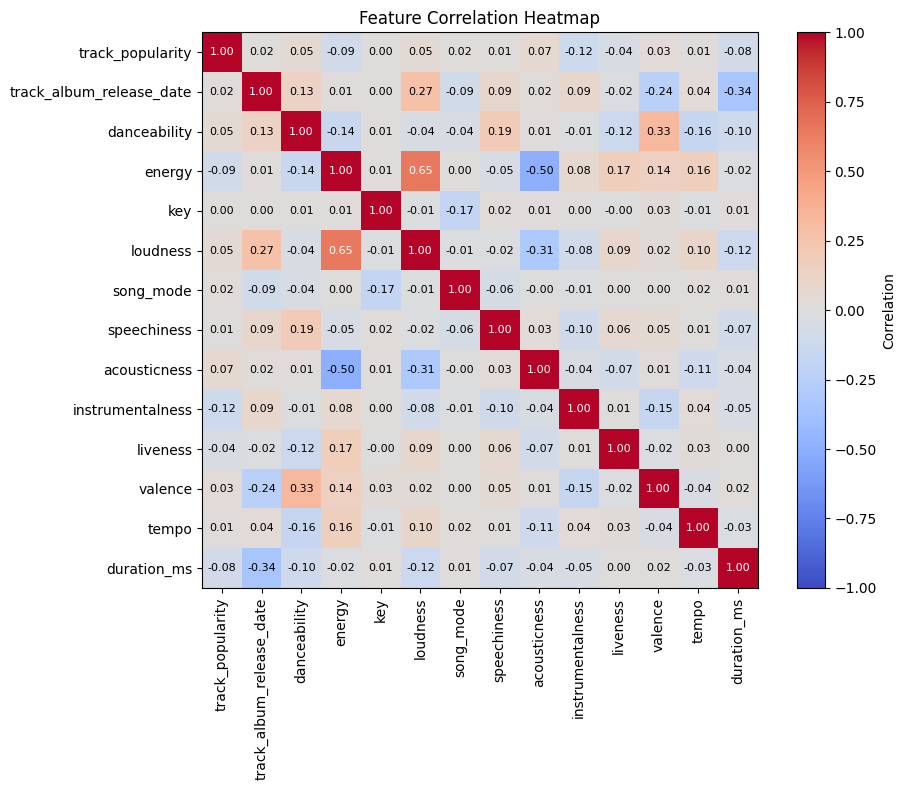

In [19]:
import matplotlib.pyplot as plt

corr = data_frame.select_dtypes(include="number").corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        value = corr.iloc[i, j]
        text_color = "white" if abs(value) > 0.5 else "black"
        plt.text(
            j, i, f"{value:.2f}", ha="center", va="center", color=text_color, fontsize=8
        )
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

#### Save the wrangled and engineered data to CSV

In [16]:
data_frame.to_csv('../2.3.Model_Training/model_ready_data.csv', index=False)